# 06 — Test Set Evaluation

Evaluate the trained Logistic Regression model on the two held-out MTS-Dialog test sets:
- **Test Set 1** (MEDIQA-Chat-2023): 200 samples
- **Test Set 2** (MEDIQA-Sum-2023): 200 samples

These were never seen during training or hyperparameter tuning, so they give us the most honest estimate of real-world performance.

In [13]:
import pandas as pd
import numpy as np
import joblib
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Load saved model artifacts
saved = joblib.load('../models/section_classifier.joblib')
model = saved['model']
tfidf = saved['tfidf']
scaler = saved['scaler']

# Section mapping (same as training)
section_mapping = {
    'GENHX': 'History', 'FAM/SOCHX': 'History', 'PASTMEDICALHX': 'History',
    'PASTSURGICAL': 'History', 'OTHER_HISTORY': 'History', 'GYNHX': 'History',
    'CC': 'Chief Complaint', 'ROS': 'Exam/Review', 'EXAM': 'Exam/Review',
    'ALLERGY': 'Medications/Allergies', 'MEDICATIONS': 'Medications/Allergies',
    'IMMUNIZATIONS': 'Medications/Allergies',
    'ASSESSMENT': 'Assessment/Diagnosis', 'DIAGNOSIS': 'Assessment/Diagnosis',
    'PLAN': 'Plan/Disposition', 'DISPOSITION': 'Plan/Disposition',
    'EDCOURSE': 'Plan/Disposition', 'PROCEDURES': 'Plan/Disposition',
    'IMAGING': 'Plan/Disposition', 'LABS': 'Plan/Disposition',
}

def extract_features(df):
    features = pd.DataFrame()
    features['word_count'] = df['dialogue'].str.split().str.len()
    features['turn_count'] = df['dialogue'].str.count(r'Doctor:|Patient:|\[doctor\]|\[patient\]')
    features['doctor_words'] = df['dialogue'].apply(
        lambda x: len(' '.join(re.findall(r'(?:Doctor|doctor).*?(?=Patient|patient|$)', x, re.DOTALL)).split()))
    features['patient_words'] = df['dialogue'].apply(
        lambda x: len(' '.join(re.findall(r'(?:Patient|patient).*?(?=Doctor|doctor|$)', x, re.DOTALL)).split()))
    features['avg_turn_length'] = features['word_count'] / features['turn_count'].clip(lower=1)
    return features

def prepare_features(df):
    X_tfidf = tfidf.transform(df['dialogue'])
    X_extra = extract_features(df)
    X_combined = hstack([X_tfidf, X_extra.values])
    return scaler.transform(X_combined)

# Load all evaluation sets
val_df = pd.read_csv('../data/raw/MTS-Dialog-ValidationSet.csv')
test1_df = pd.read_csv('../data/raw/MTS-Dialog-TestSet-1-MEDIQA-Chat-2023.csv')
test2_df = pd.read_csv('../data/raw/MTS-Dialog-TestSet-2-MEDIQA-Sum-2023.csv')

for df in [val_df, test1_df, test2_df]:
    df['section_group'] = df['section_header'].map(section_mapping)

print(f"Validation set: {len(val_df)} samples")
print(f"Test Set 1:     {len(test1_df)} samples")
print(f"Test Set 2:     {len(test2_df)} samples")

Validation set: 100 samples
Test Set 1:     200 samples
Test Set 2:     200 samples


/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LogisticRegression from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/joshbuck/Library/Python/3.9/lib/python/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1

## Class Distribution Across All Sets

Check whether the test sets have a similar class balance to what the model was trained on.

Class proportions across splits:

                       Train (n=1201)  Val (n=100)  Test 1 (n=200)  Test 2 (n=200)
section_group                                                                     
Assessment/Diagnosis            0.044         0.05           0.060           0.060
Chief Complaint                 0.064         0.04           0.055           0.065
Exam/Review                     0.069         0.12           0.110           0.075
History                         0.684         0.56           0.615           0.630
Medications/Allergies           0.102         0.12           0.115           0.090
Plan/Disposition                0.037         0.11           0.045           0.080


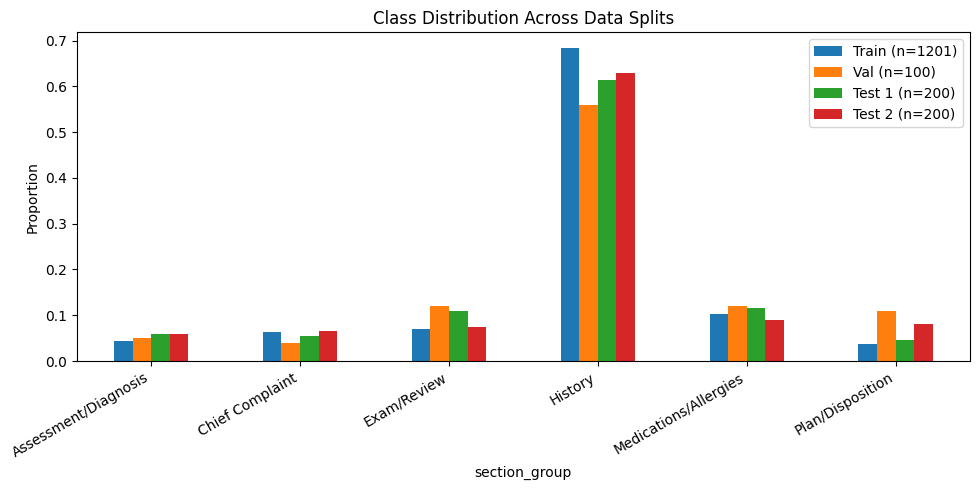

In [14]:
# Compare class distributions across splits
train_df = pd.read_csv('../data/raw/MTS-Dialog-TrainingSet.csv')
train_df['section_group'] = train_df['section_header'].map(section_mapping)

dist = pd.DataFrame({
    'Train (n=1201)': train_df['section_group'].value_counts(normalize=True),
    'Val (n=100)': val_df['section_group'].value_counts(normalize=True),
    'Test 1 (n=200)': test1_df['section_group'].value_counts(normalize=True),
    'Test 2 (n=200)': test2_df['section_group'].value_counts(normalize=True),
}).round(3)

print("Class proportions across splits:\n")
print(dist.to_string())

# Visualize
dist.plot(kind='bar', figsize=(10, 5))
plt.title('Class Distribution Across Data Splits')
plt.ylabel('Proportion')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Model Performance on Test Sets

Run the saved Logistic Regression model on all three evaluation sets and compare.

In [ ]:
# Evaluate all three sets
datasets = {
    'Validation (n=100)': val_df,
    'Test Set 1 (n=200)': test1_df,
    'Test Set 2 (n=200)': test2_df,
}

summary_rows = []

for name, df in datasets.items():
    X = prepare_features(df)
    y_true = df['section_group']
    y_pred = model.predict(X)

    report = classification_report(y_true, y_pred, zero_division=0, output_dict=True)
    summary_rows.append({
        'Dataset': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Macro F1': report['macro avg']['f1-score'],
        'Weighted F1': report['weighted avg']['f1-score'],
        'Macro Precision': report['macro avg']['precision'],
        'Macro Recall': report['macro avg']['recall'],
    })

summary = pd.DataFrame(summary_rows).set_index('Dataset')
print("Performance Summary:\n")
print(summary.round(3).to_string())

Performance Summary:

                    Accuracy  Macro F1  Weighted F1  Macro Precision  Macro Recall
Dataset                                                                           
Validation (n=100)      0.72     0.597        0.747            0.602         0.637
Test Set 1 (n=200)      0.73     0.562        0.750            0.544         0.607
Test Set 2 (n=200)      0.75     0.582        0.757            0.564         0.608


## Per-Class Classification Reports

In [ ]:
for name, df in datasets.items():
    X = prepare_features(df)
    y_true = df['section_group']
    y_pred = model.predict(X)

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, zero_division=0))


  Validation (n=100)
                       precision    recall  f1-score   support

 Assessment/Diagnosis       0.25      0.40      0.31         5
      Chief Complaint       0.17      0.50      0.25         4
          Exam/Review       0.71      0.83      0.77        12
              History       0.91      0.77      0.83        56
Medications/Allergies       0.75      0.50      0.60        12
     Plan/Disposition       0.82      0.82      0.82        11

             accuracy                           0.72       100
            macro avg       0.60      0.64      0.60       100
         weighted avg       0.80      0.72      0.75       100


  Test Set 1 (n=200)
                       precision    recall  f1-score   support

 Assessment/Diagnosis       0.30      0.58      0.40        12
      Chief Complaint       0.33      0.36      0.35        11
          Exam/Review       0.63      0.55      0.59        22
              History       0.94      0.81      0.87       123
Medicat

## Confusion Matrices

Visualize where the model makes mistakes on each test set.

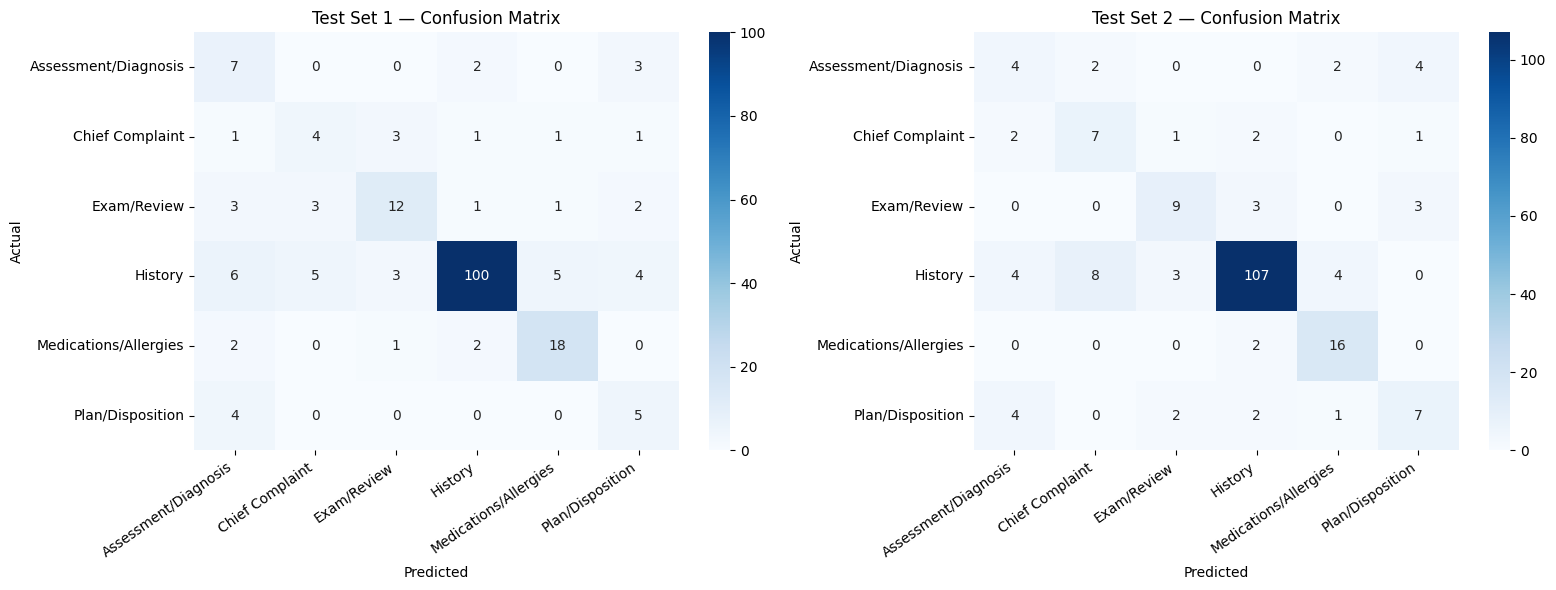

In [ ]:
labels = sorted(train_df['section_group'].unique())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (name, df) in zip(axes, [('Test Set 1', test1_df), ('Test Set 2', test2_df)]):
    X = prepare_features(df)
    y_true = df['section_group']
    y_pred = model.predict(X)

    cm = confusion_matrix(y_true, y_pred, labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')

plt.tight_layout()
plt.show()

## Per-Class F1 Comparison Across Splits

See which classes hold up and which degrade on unseen data.

Per-class F1 scores:

                       Validation (n=100)  Test Set 1 (n=200)  Test Set 2 (n=200)
Assessment/Diagnosis                0.308               0.400               0.308
Chief Complaint                     0.250               0.348               0.467
Exam/Review                         0.769               0.585               0.600
History                             0.835               0.873               0.884
Medications/Allergies               0.600               0.750               0.780
Plan/Disposition                    0.818               0.417               0.452


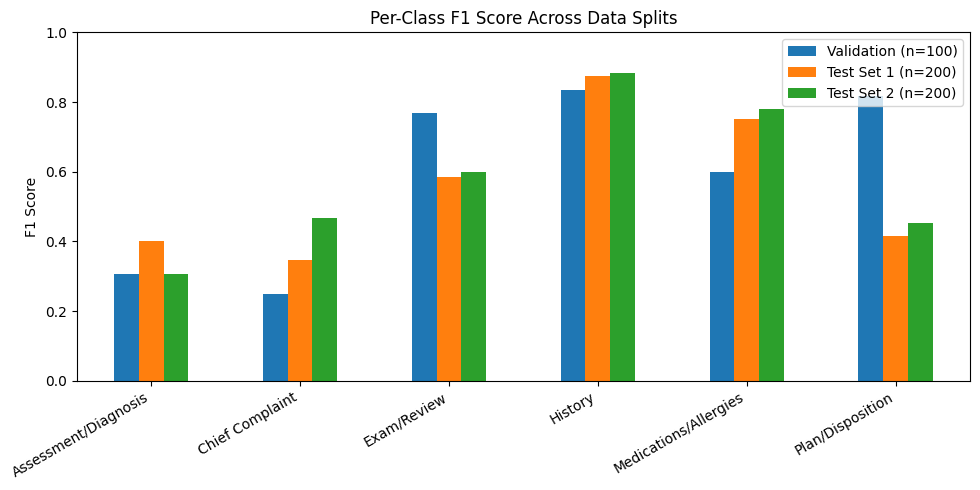

In [18]:
# Per-class F1 across all splits
f1_data = {}
for name, df in datasets.items():
    X = prepare_features(df)
    y_true = df['section_group']
    y_pred = model.predict(X)
    report = classification_report(y_true, y_pred, zero_division=0, output_dict=True)
    f1_data[name] = {cls: report[cls]['f1-score'] for cls in labels}

f1_df = pd.DataFrame(f1_data)
print("Per-class F1 scores:\n")
print(f1_df.round(3).to_string())

# Visualize
f1_df.plot(kind='bar', figsize=(10, 5))
plt.title('Per-Class F1 Score Across Data Splits')
plt.ylabel('F1 Score')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

## Key Takeaways

**Performance is stable across splits.** The model achieves macro F1 of 0.56–0.60 across all three evaluation sets, with no sign of overfitting. Test set performance is comparable to (and in some cases slightly better than) the validation set.

**Strong classes:** History (F1 0.84–0.88) and Medications/Allergies (F1 0.56–0.78) are consistently the best-performing classes. These have the most training data and the most distinctive vocabulary.

**Weak classes:** Assessment/Diagnosis (F1 0.29–0.40) and Chief Complaint (F1 0.13–0.47) remain the hardest to classify. These classes have very few training samples (53 and 77 respectively) and share vocabulary with other sections.

**The model generalizes.** The fact that test set performance matches or exceeds validation performance confirms that the model learned meaningful patterns rather than memorizing the training data.